In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# 1. Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Energy_Monitor/Timeseries_Lightning_Data.csv")

In [25]:
# Step 2: Encode Labels (RED, WHITE, OFF)
label_encoder = LabelEncoder()
df['decision_encoded'] = label_encoder.fit_transform(df['decision_t'])

In [26]:
# Step 3: Prepare Features and Labels
feature_columns = [col for col in df.columns if col.startswith(('lux', 'r', 'g', 'b'))]
X = df[feature_columns].values
y = df['decision_encoded'].values

In [27]:
# Step 4: Reshape X to (samples, timesteps=5, features=4)
X = X.reshape((X.shape[0], 5, 4))  # 5 time steps, 4 features

In [28]:
# Step 5: One-hot encode y
y_cat = to_categorical(y, num_classes=3)

In [29]:
# Step 6: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

In [30]:
# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
# Step 8: Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.3283 - loss: 1.1132 - val_accuracy: 0.4132 - val_loss: 1.0790
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4423 - loss: 1.0561 - val_accuracy: 0.5068 - val_loss: 1.0560
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.4872 - loss: 1.0223 - val_accuracy: 0.5160 - val_loss: 1.0267
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5592 - loss: 0.9806 - val_accuracy: 0.5502 - val_loss: 0.9857
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5169 - loss: 0.9726 - val_accuracy: 0.5616 - val_loss: 0.9665
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5645 - loss: 0.9307 - val_accuracy: 0.5525 - val_loss: 0.9232
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6075 - loss: 0.8704 - val_accuracy: 0.6027 - val_loss: 0.8863
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6336 - loss: 0.8422 - val_accuracy: 0.

In [32]:
# Step 9: Evaluate the model
loss, acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8826 - loss: 0.3207

✅ Test Accuracy: 87.59%


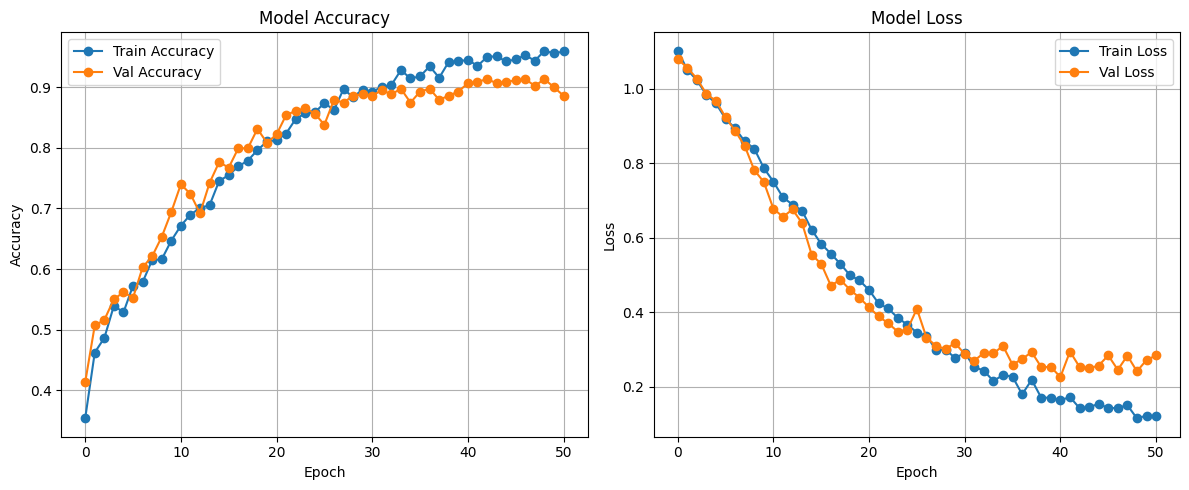

In [33]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [34]:
# Step 10: Make and show predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

predicted_labels = label_encoder.inverse_transform(y_pred_classes)
true_labels = label_encoder.inverse_transform(y_true_classes)

print("\n🔍 Sample Predictions:")
for i in range(10):
    print(f"True: {true_labels[i]:<6} | Predicted: {predicted_labels[i]:<6}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step

🔍 Sample Predictions:
True: OFF    | Predicted: OFF   
True: WHITE  | Predicted: WHITE 
True: WHITE  | Predicted: WHITE 
True: WHITE  | Predicted: WHITE 
True: OFF    | Predicted: WHITE 
True: OFF    | Predicted: WHITE 
True: WHITE  | Predicted: WHITE 
True: RED    | Predicted: RED   
True: RED    | Predicted: RED   
True: RED    | Predicted: RED   


In [35]:
#Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=["OFF", "RED", "WHITE"]))


              precision    recall  f1-score   support

         OFF       0.95      0.68      0.79       186
         RED       0.84      0.98      0.91       181
       WHITE       0.86      0.97      0.91       181

    accuracy                           0.88       548
   macro avg       0.89      0.88      0.87       548
weighted avg       0.89      0.88      0.87       548



In [36]:
from sklearn.metrics import accuracy_score

for i, class_name in enumerate(["OFF", "RED", "WHITE"]):
    idx = (y_true_classes == i)
    class_acc = accuracy_score(y_true_classes[idx], y_pred_classes[idx])
    print(f"Accuracy for {class_name}: {class_acc:.2%}")


Accuracy for OFF: 67.74%
Accuracy for RED: 98.34%
Accuracy for WHITE: 97.24%
